# Constants

In [143]:
import os
import torch

BATCH_SIZE = 2
NUM_EPOCHS = 10
LEARNING_RATE = 5e-6
WEIGHT_DECAY = 1e-4

NUM_WORKERS = os.cpu_count()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

ROOT_DIR = "NN/Penguins/"
DATA_DIR = "data/"

# Image size
ORIGINAL_IMAGE_HEIGHT = 1536
ORIGINAL_IMAGE_WIDTH = 2048
TOP_OFFSET = 32
BOTTOM_OFFSET = 32

IMAGE_HEIGHT = ORIGINAL_IMAGE_HEIGHT - TOP_OFFSET - BOTTOM_OFFSET
IMAGE_WIDTH = 2048
IMAGE_SIZE = (IMAGE_WIDTH, IMAGE_HEIGHT)

RESIZE_COEFF = 1 / 2
FINAL_IMAGE_HEIGHT = int(IMAGE_HEIGHT * RESIZE_COEFF)
FINAL_IMAGE_WIDTH = int(IMAGE_WIDTH  * RESIZE_COEFF)
FINAL_IMAGE_SIZE = (FINAL_IMAGE_WIDTH, FINAL_IMAGE_HEIGHT)
print(IMAGE_SIZE)
print(FINAL_IMAGE_SIZE)

MAX_PENGUINS = 100

cuda
(2048, 1472)
(1024, 736)


# Preparing data

## Loading images

In [72]:
import random
import glob

from PIL import Image

# Set random seed
# random.seed(0)
random.seed()

image_path_list = glob.glob(f"{DATA_DIR}/*/DCIM/*/*.JPG")

### Visualization of random image

Random image path: data/PTI3/DCIM/Pictures/IMG_3533.JPG
Image height: 1536
Image width: 2048


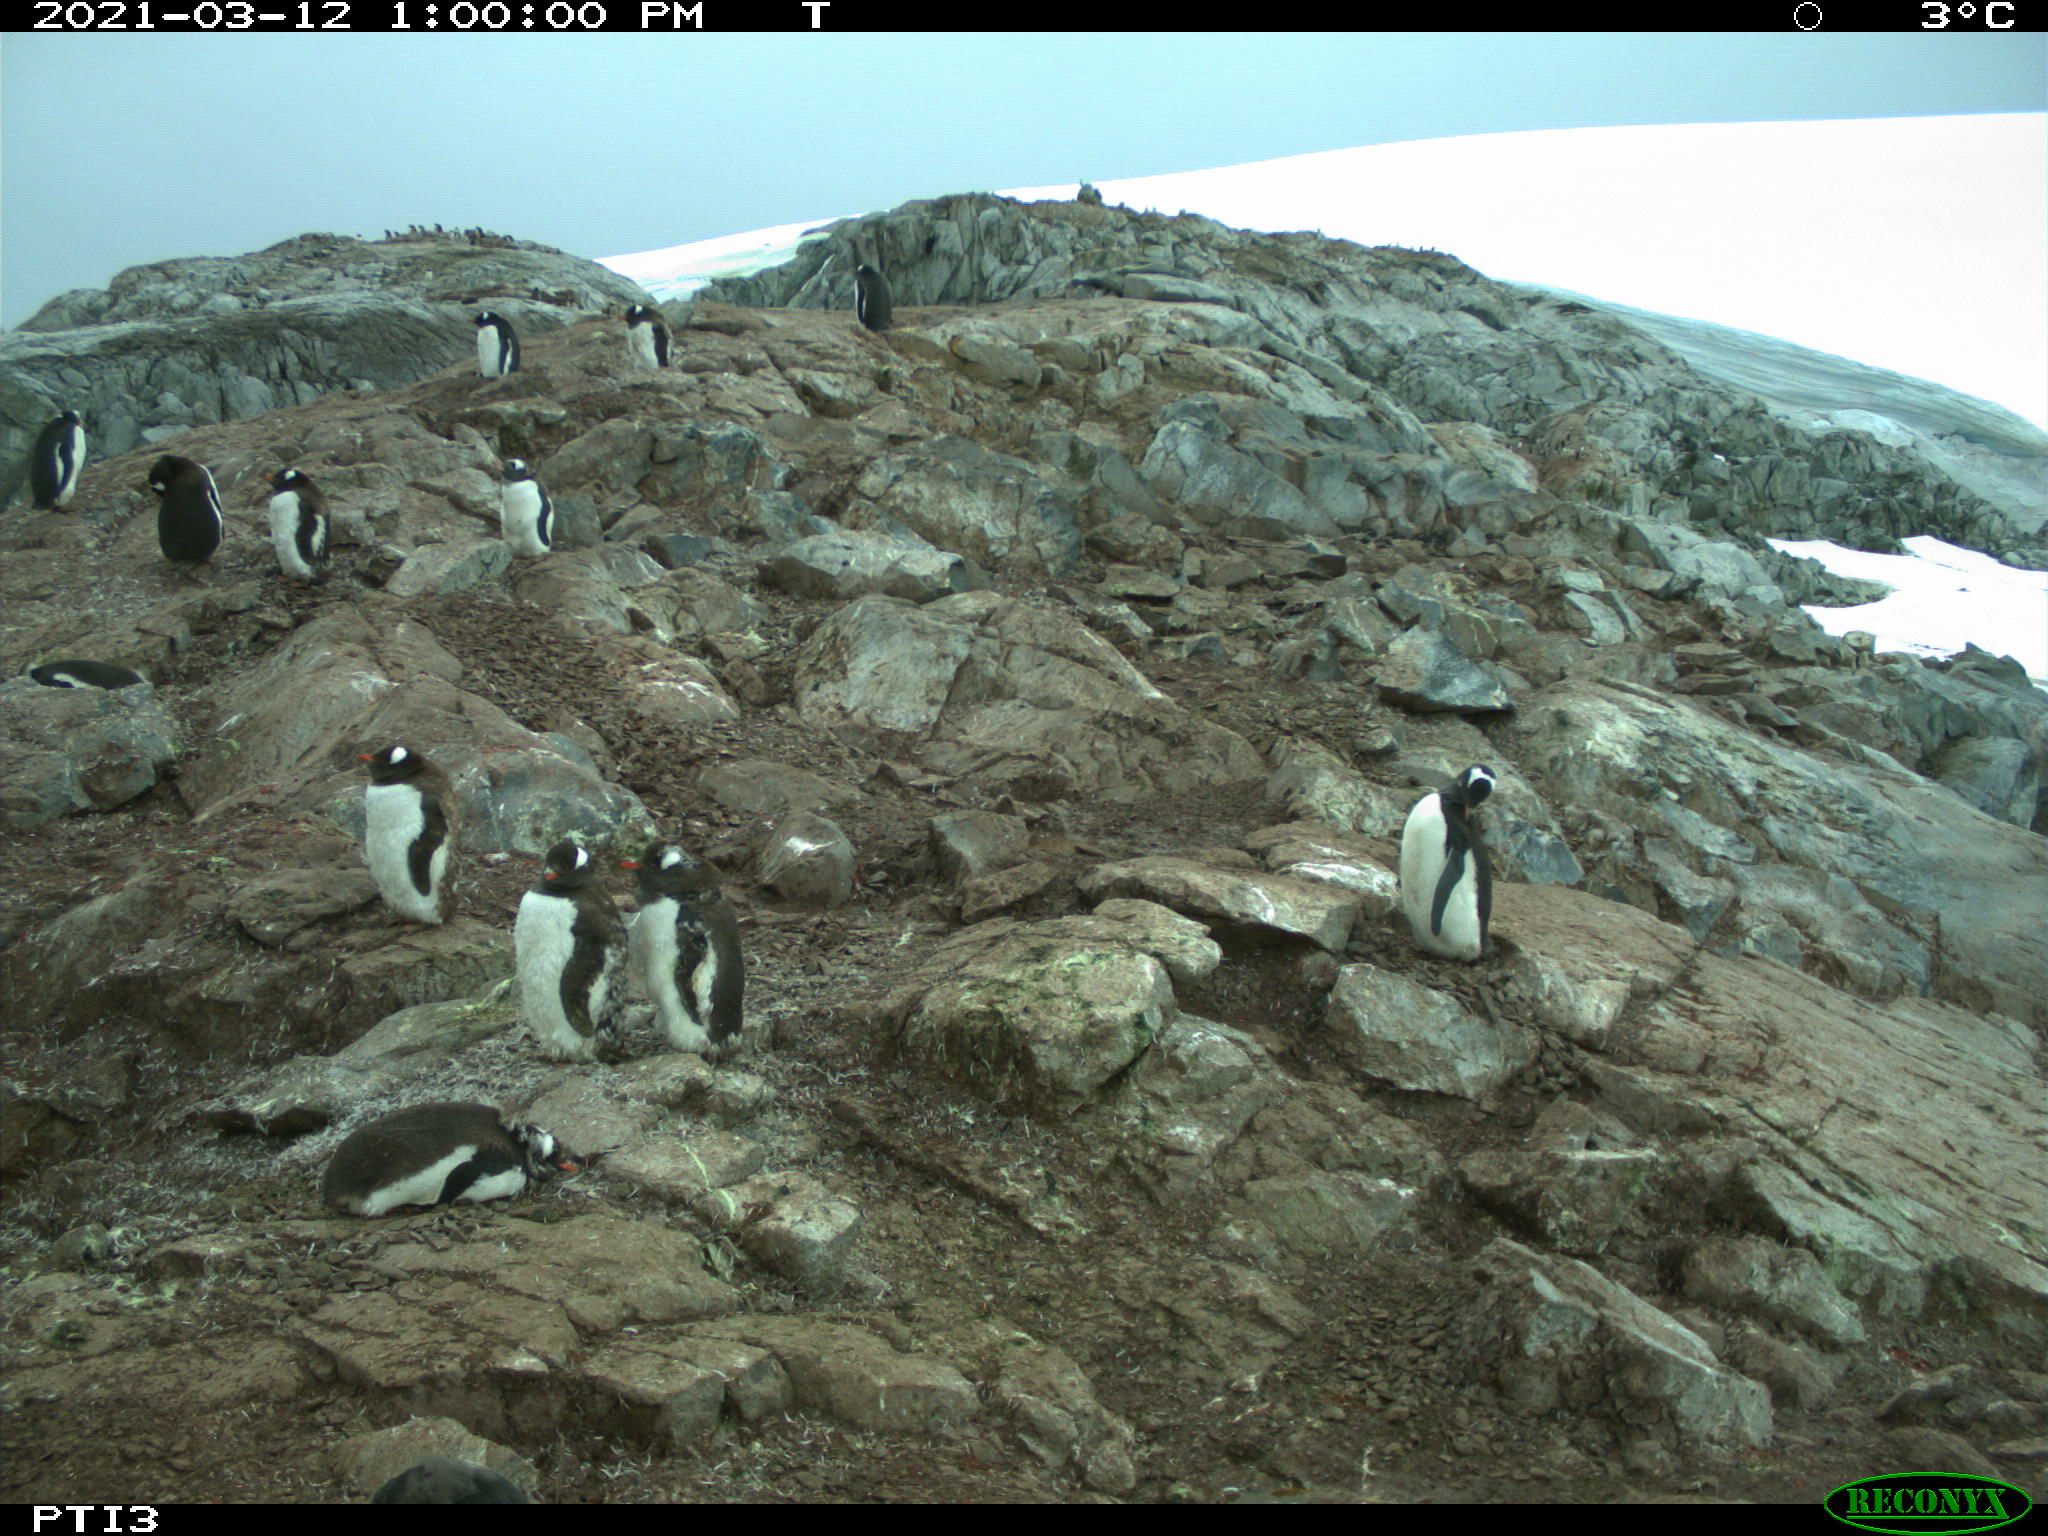

In [70]:
def visualize_random_image(image_paths: list, random_seed: int=0):
    random.seed(random_seed)

    random_image_path = random.choice(image_paths)

    random_img = Image.open(random_image_path)

    # Print metadata
    print(f"Random image path: {random_image_path}")
    # print(f"Image class: {image_class}")
    print(f"Image height: {random_img.height}")
    print(f"Image width: {random_img.width}")

    return random_img

visualize_random_image(image_path_list)

#### MatPlotLib

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_random_image_mpl_edition(image_paths: list, random_seed: int=0):
    random.seed(random_seed)

    random_image_path = random.choice(image_paths)

    random_img = Image.open(random_image_path)

    img_as_array = np.asarray(random_img)

    plt.figure(figsize=(10, 10))
    plt.imshow(img_as_array)
    plt.title(f"Image shape: {img_as_array.shape} -> [height, width, color_channels]")
    plt.axis(False)

visualize_random_image(image_path_list)

## Transforming images

In [144]:
from torchvision import transforms
import torchvision.transforms.functional as t_F
from pathlib import Path

class FixedCrop:
    def __init__(self, top, left, size: tuple[int, int]):
        self.top = top
        self.left = left
        self.height = size[0]
        self.width = size[1]

    def __call__(self, img):
        return t_F.crop(img, self.top, self.left, self.height, self.width)

data_transforms = transforms.Compose([
    FixedCrop(top=TOP_OFFSET, left=0, size=IMAGE_SIZE[::-1]),

    transforms.Resize(FINAL_IMAGE_SIZE[::-1]),

    transforms.RandomHorizontalFlip(p=0.5),
    #transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.5, saturation=0.5, hue=0.5),
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5.)),
    transforms.ToTensor()
])

### MatPlotLib visualization of transformed images

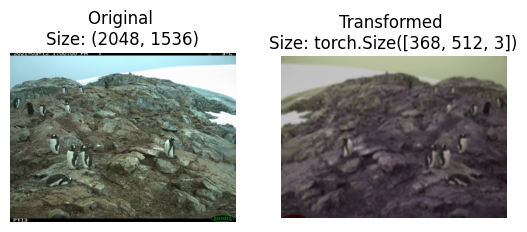

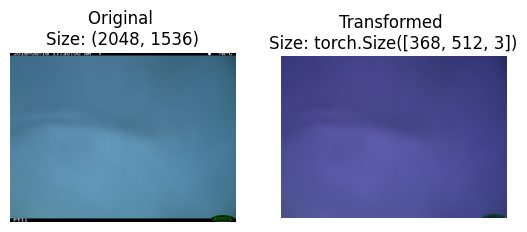

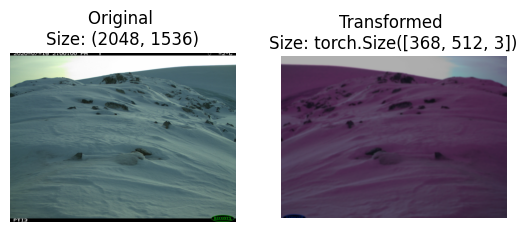

In [74]:
import matplotlib.pyplot as plt

def plot_transformed_images(image_paths: list,
                            transform,
                            num_images: int = 3,
                            random_seed: int = 0
                            ):
    random.seed(random_seed)
    random_image_paths = random.sample(image_paths, k=num_images)

    for image_path in random_image_paths:
        with Image.open(image_path) as img_file:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(img_file)
            ax[0].set_title(f"Original \nSize: {img_file.size}")
            ax[0].axis("off")

            # Transforming image
            transformed_image = transform(img_file).permute(1, 2, 0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")
            # fig.suptitle(
            #     f"Class: {Path(random_image_path).parent.stem}",
            #     fontsize=16
            # )

plot_transformed_images(image_path_list, transform=data_transforms, num_images=3)

## Custom Dataclass

In [75]:
import os
import json
import glob
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pprint import pprint

class CustomImageDataset(Dataset):
    """
    Спеціальний клас набору даних для структури, де зображення знаходяться
    в теках DCIM, а відповіді (мітки) - у JSON-файлах в теці ANSWERS.
    """
    def __init__(self, root_dir, max_target=MAX_PENGUINS, transform=None):
        """
        Args:
            root_dir (string): Шлях до головної теки з даними (наприклад, 'data').
            transform (callable, optional): Необов'язкові перетворення,
                                            що застосовуються до зразка.
        """
        self.root_dir = root_dir
        self.max_target = max_target
        self.transform = transform
        self.samples = [] # Тут ми будемо зберігати пари (шлях_до_зображення, мітка)
        self.classes = []

        # Перевіряємо, чи існує коренева тека
        if not os.path.isdir(self.root_dir):
            raise FileNotFoundError(f"Root directory not found: {self.root_dir}")

        # Проходимо по всіх підтеках у root_dir (наприклад, 'PTI1', 'PTI2')
        for dir_name in os.listdir(self.root_dir):
            path = os.path.join(self.root_dir, dir_name)
            if not os.path.isdir(path):
                continue

            answers_dir = os.path.join(path, 'ANSWERS')
            dcim_dir = os.path.join(path, 'DCIM')

            # Перевіряємо наявність необхідних тек
            if not os.path.isdir(answers_dir) or not os.path.isdir(dcim_dir):
                print(f"Warning: Skipping {path} because it's missing ANSWERS or DCIM directory.")
                continue

            # Проходимо по всіх JSON-файлах у теці ANSWERS
            for answer_file_name in os.listdir(answers_dir):
                if not answer_file_name.endswith('.json'):
                    continue

                answer_file_path = os.path.join(answers_dir, answer_file_name)

                # Завантажуємо дані з JSON
                with open(answer_file_path, 'r', encoding='utf-8') as f:
                    try:
                        answers = json.loads(f.read())
                        print(answers)
                    except json.JSONDecodeError:
                        print(f"Warning: Could not decode JSON from {answer_file_path}")
                        continue

                # Назва теки з зображеннями відповідає назві JSON-файлу без розширення
                image_dir_name = os.path.splitext(answer_file_name)[0]
                image_dir_path = os.path.join(dcim_dir, image_dir_name)

                if not os.path.isdir(image_dir_path):
                    print(f"Warning: Corresponding image directory not found for {answer_file_name} at {image_dir_path}")
                    continue

                # Створюємо список зразків для цієї теки
                for img_name, label in answers.items():
                    # Використовуємо glob для пошуку файлу зображення з будь-яким
                    # поширеним розширенням, щоб не залежати від .jpg, .png тощо.
                    # Це знаходить файли типу IMG_XXXX.jpg, IMG_XXXX.png і т.д.
                    image_path_pattern = os.path.join(image_dir_path, f"{img_name}.*")
                    found_images = glob.glob(image_path_pattern)

                    if found_images:
                        # Беремо перший знайдений файл
                        self.samples.append((found_images[0], label))
                        self.classes.append(label)
                    else:
                        print(f"Warning: Image file for '{img_name}' not found in {image_dir_path}")


    def __len__(self):
        """
        Повертає загальну кількість зразків (зображень) у наборі даних.
        """
        return len(self.samples)

    def __getitem__(self, idx):
        """
        Повертає один зразок (зображення та мітку) за індексом.
        Args:
            idx (int): Індекс зразка.
        """
        # Отримуємо шлях до зображення та його мітку за індексом
        img_path, label = self.samples[idx]

        # Відкриваємо зображення за допомогою Pillow
        # Конвертуємо в RGB, щоб уникнути проблем з одноканальними (ч/б)
        # або чотириканальними (з альфа-каналом) зображеннями.
        try:
            image = Image.open(img_path).convert('RGB')
        except IOError:
            print(f"Error opening image file: {img_path}")
            # Повертаємо порожній тензор та мітку -1 у разі помилки
            # Це потрібно буде обробити у вашому циклі навчання
            return torch.zeros(3, IMAGE_HEIGHT, IMAGE_WIDTH), -1

        # Застосовуємо перетворення, якщо вони є
        if self.transform:
            image = self.transform(image)
            label = torch.tensor(label)

        # Нормалізація відповідей
        normalized_label = label / self.max_target

        # Повертаємо зображення (вже як тензор) та його мітку
        return image, label

# --- Приклад використання ---
# if __name__ == '__main__':
#     # Створюємо екземпляр нашого набору даних
#     # Вказуємо шлях до кореневої теки 'data'
#     print("Initializing CustomImageDataset...")
#     custom_dataset = CustomImageDataset(root_dir=DATA_DIR, transform=data_transforms)
#     print(f"Dataset created successfully. Total samples found: {len(custom_dataset)}\n")
#
#     # Перевіримо, що зразки завантажились правильно
#     print("Samples found by the dataset class:")
#     for i, (path, label) in enumerate(custom_dataset.samples):
#         print(f"  Sample {i}: Path='{path}', Label={label}")
#     print("-" * 30)
#
#     # Створюємо DataLoader для пакетної подачі даних
#     # Це стандартна практика в PyTorch
#     dataloader = DataLoader(custom_dataset, batch_size=2, shuffle=True, num_workers=0)
#     print("\nDataLoader created. Fetching one batch...")
#
#     # Отримуємо один батч (пакет) даних
#     images, labels = next(iter(dataloader))
#
#     # Виводимо інформацію про батч
#     print(f"Batch of images shape: {images.shape}") # Очікуємо [batch_size, channels, height, width]
#     print(f"Batch of labels: {labels}")
#     print(f"Labels data type: {labels.dtype}")



## Creating datasets

In [145]:
from torchvision import datasets
from torch.utils.data import DataLoader, random_split

full_dataset = CustomImageDataset(root_dir=DATA_DIR, transform=data_transforms)

train_dataset, valid_dataset, test_dataset = random_split(full_dataset, [0.70, 0.15, 0.15])
print(len(train_dataset))
print(len(valid_dataset))
print(len(test_dataset))



{'IMG_0001': 9, 'IMG_0002': 17, 'IMG_0003': 22, 'IMG_0004': 19, 'IMG_0005': 6, 'IMG_0006': 9, 'IMG_0007': 0, 'IMG_0008': 0, 'IMG_0009': 0, 'IMG_0010': 0, 'IMG_0011': 0, 'IMG_0012': 0, 'IMG_0013': 0, 'IMG_0014': 0, 'IMG_0015': 5, 'IMG_0016': 8, 'IMG_0017': 0, 'IMG_0018': 1, 'IMG_0019': 0, 'IMG_0020': 0, 'IMG_0021': 1, 'IMG_0022': 0, 'IMG_0023': 0, 'IMG_0024': 0, 'IMG_0025': 1, 'IMG_0026': 0, 'IMG_0027': 1, 'IMG_0028': 1, 'IMG_0029': 1, 'IMG_0030': 1, 'IMG_0031': 1, 'IMG_0032': 0, 'IMG_0033': 0, 'IMG_0034': 0, 'IMG_0035': 0, 'IMG_0036': 3, 'IMG_0037': 5, 'IMG_0038': 5, 'IMG_0039': 4, 'IMG_0040': 3, 'IMG_0041': 4, 'IMG_0042': 3, 'IMG_0043': 3, 'IMG_0044': 2, 'IMG_0045': 14, 'IMG_0046': 21, 'IMG_0047': 1, 'IMG_0048': 1, 'IMG_0049': 2, 'IMG_0050': 3, 'IMG_0051': 2, 'IMG_0052': 4, 'IMG_0053': 3, 'IMG_0054': 9, 'IMG_0055': 1, 'IMG_0056': 0, 'IMG_0057': 1, 'IMG_0058': 1, 'IMG_0059': 1, 'IMG_0060': 3, 'IMG_0061': 22, 'IMG_0062': 21, 'IMG_0063': 19, 'IMG_0064': 18, 'IMG_0065': 28, 'IMG_0066': 38

In [146]:
full_dataloader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=BATCH_SIZE, # how many samples per batch?
                              num_workers=NUM_WORKERS,
                              shuffle=True) # shuffle the data?

valid_dataloader = DataLoader(dataset=valid_dataset,
                              batch_size=BATCH_SIZE, # how many samples per batch?
                              num_workers=NUM_WORKERS,
                              shuffle=False) # shuffle the data?

test_dataloader = DataLoader(dataset=test_dataset,
                             batch_size=BATCH_SIZE,
                             num_workers=NUM_WORKERS,
                             shuffle=False) # don't usually need to shuffle testing data

# Model

## RegressionCNN Model class

In [41]:
import torch.nn as nn
import torch.nn.functional as nn_F


class RegressionCNN(nn.Module):
    def __init__(self, in_channels=3, num_outputs=1):
        """
        A deeper CNN designed for regression tasks like object counting.

        Parameters:
            * in_channels: Number of channels in the input image (3 for RGB).
            * num_outputs: Number of output values. For counting, this is 1.
        """
        super(RegressionCNN, self).__init__()

        # --- Convolutional Blocks ---
        # Each block consists of Conv -> BatchNorm -> ReLU -> MaxPool
        self.block1 = self._create_block(in_channels, 16)
        self.block2 = self._create_block(16, 32)
        self.block3 = self._create_block(32, 64)
        #self.block4 = self._create_block(64, 128)
        #self.block5 = self._create_block(128, 256)
        #self.block6 = self._create_block(256, 512)
        #self.block7 = self._create_block(512, 1024)

        # --- Adaptive Pooling and Classifier ---
        # This layer ensures the output spatial size is always consistent (e.g., 7x7)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))

        # --- Classifier (Fully Connected Layers) ---
        # We add a hidden layer for more capacity. Dropout helps prevent overfitting.
        self.classifier = nn.Sequential(
            nn.Flatten(), # This replaces the .view() call in the forward pass
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.55),
            nn.Linear(512, num_outputs)
        )

    def _create_block(self, in_c, out_c):
        """Helper function to create a standard convolutional block."""
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

    def forward(self, x):
        """
        Defines the forward pass of the CNN.
        """
        # Pass through the convolutional blocks
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        #x = self.block4(x)
        #x = self.block5(x)
        #x = self.block6(x)
        #x = self.block7(x)

        # Apply adaptive pooling
        x = self.adaptive_pool(x)

        # Pass through the classifier
        x = self.classifier(x)

        return x

## ResNet Model class

In [154]:
import torch.nn as nn
import torch.nn.functional as nn_F

class ResidualBlock(nn.Module):
    # Це є "серце" ResNet - блок зі skip connection
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut connection для зміни розмірів
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = nn_F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        # Додаємо shortcut до виходу. Він буде або x, або трансформований x.
        out += self.shortcut(x)
        return nn_F.relu(out)

class BabyResNet(nn.Module):
    # Наша власна маленька ResNet
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        # Початковий шар
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Кілька наших залишкових блоків
        self.res_block1 = ResidualBlock(32, 32)
        self.res_block2 = ResidualBlock(32, 64, stride=2)
        self.res_block3 = ResidualBlock(64, 64)
        self.res_block4 = ResidualBlock(64, 128, stride=2)
        # self.res_block5 = ResidualBlock(128, 128)

        # Голова для регресії
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, out_channels)

    def forward(self, x):
        out = nn_F.relu(self.bn1(self.conv1(x)))
        out = self.res_block1(out)
        out = self.res_block2(out)
        out = self.res_block3(out)
        out = self.res_block4(out)
#         out = self.res_block5(out)
        out = self.pool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

## Model creating

In [155]:
# model = RegressionCNN(in_channels=3, num_outputs=1).to(DEVICE)
model = BabyResNet(in_channels=3, out_channels=1).to(DEVICE)

# print(model)

# Training

## Settings

In [156]:
import torch.optim as optim
from tqdm import tqdm

# Define the loss function
criterion = nn.L1Loss()

# Define the optimizer
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

best_validation_loss = float('inf')

## Train loop

In [169]:
for epoch in range(NUM_EPOCHS):
    # Iterate over training batches
    print("="*30)
    print()
    print(f"Epoch [{epoch + 1}/{NUM_EPOCHS}]")

    # Train phase
    print(f"    {"="*5} TRAINING {"="*5}")

    model.train()
    total_train_loss = 0

    for batch_index, (data, targets) in enumerate(tqdm(train_dataloader)):
        data = data.to(DEVICE)
        targets = targets.to(DEVICE).float().unsqueeze(1) # Змінюємо тип і додаємо розмірність
        predictions = model(data)
        loss = criterion(predictions, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    # Validation phase
    print(f"    {"="*5} VALIDATION {"="*5}")

    model.eval()
    total_validation_loss = 0

    with torch.no_grad():
        for batch_index, (data, targets) in enumerate(tqdm(valid_dataloader)):
            data = data.to(DEVICE)
            targets = targets.to(DEVICE).float().unsqueeze(1)
            predictions = model(data)
            loss = criterion(predictions, targets)

            total_validation_loss += loss.item()

    # Analys
    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_validation_loss = total_validation_loss / len(valid_dataloader)

    print(f"        Train Loss: {avg_train_loss:.4f}")
    print(f"        Validation Loss: {avg_validation_loss:.4f}")

    if avg_validation_loss < best_validation_loss:
        print("  Validation Loss покращився! Зберігаємо модель...")
        best_validation_loss = avg_validation_loss
        torch.save(model.state_dict(), 'best_model_200samples_ResNet_LastTry_ForthTeach.pth')

    print()
    print()


Epoch [1/10]
    ===== TRAINING =====


100%|██████████| 70/70 [00:24<00:00,  2.87it/s]


    ===== VALIDATION =====


100%|██████████| 15/15 [00:02<00:00,  5.28it/s]


        Train Loss: 7.2068
        Validation Loss: 9.0864



Epoch [2/10]
    ===== TRAINING =====


...

        Train Loss: 7.1865
        Validation Loss: 8.6655



Epoch [10/10]
    ===== TRAINING =====


100%|██████████| 70/70 [00:25<00:00,  2.79it/s]


    ===== VALIDATION =====


100%|██████████| 15/15 [00:03<00:00,  4.90it/s]

        Train Loss: 7.0562
        Validation Loss: 9.0321




## Test model

In [170]:
import torch
from torchmetrics.regression import MeanAbsoluteError


# 1. Створюємо нову "чисту" модель з тією ж архітектурою
# best_model = RegressionCNN()
best_model = BabyResNet(in_channels=3, out_channels=1)

# 2. Завантажуємо в неї найкращі ваги, які ми зберегли
best_model.load_state_dict(torch.load(f'best_model_200samples_ResNet_LastTry_ForthTeach.pth'))

# 3. Переміщуємо модель на GPU і вмикаємо режим оцінки
best_model.to(DEVICE)
best_model.eval()

# Створюємо екземпляр метрики
mae = MeanAbsoluteError().to(DEVICE)

best_model.eval() # Переводимо модель у режим оцінки
with torch.no_grad(): # Вимикаємо обчислення градієнтів
   for images, labels in test_dataloader:
       images = images.to(DEVICE)
       labels = labels.to(DEVICE).unsqueeze(1) # Готуємо мітки

       # Отримуємо передбачення від моделі
       predictions = best_model(images)

       # Оновлюємо метрику
       mae.update(predictions, labels)

# Обчислюємо фінальне значення MAE по всіх даних
total_mae = mae.compute()
print(f"Test MAE: {total_mae:.4f}")
# Це покаже, на скільки яблук в середньому помиляється модель

Test MAE: 7.3618


### Not general test

### Worst results

In [171]:
mae = MeanAbsoluteError().to(DEVICE)
results = [] # Створюємо список для збереження результатів

best_model.eval()
with torch.no_grad():
    for images, normalized_labels in test_dataloader:
        images_cpu = images.cpu()
        images = images.to(DEVICE)
        normalized_labels = normalized_labels.to(DEVICE).unsqueeze(1)

        normalized_predictions = best_model(images)

        # ================== ЗМІНИ ТУТ ==================
        # Де-нормалізуємо для метрики та для збереження
        real_predictions = normalized_predictions# * MAX_PENGUINS
        real_labels = normalized_labels# * MAX_PENGUINS
        mae.update(real_predictions, real_labels)
        # ===============================================

        for i in range(images.size(0)):
            # ================== ЗМІНИ ТУТ ==================
            # Зберігаємо в список вже реальні, де-нормалізовані значення
            pred = real_predictions[i].item()
            label = real_labels[i].item()
            error = abs(pred - label)

            results.append({
                "error": error,
                "prediction": pred,
                "label": label,
                "image": images_cpu[i]
            })
            # ===============================================

# Сортуємо результати за похибкою
worst_predictions = sorted(results, key=lambda x: x['error'], reverse=True)

print("Топ-5 найгірших передбачень:")
print("--------------------------------")
print("Прогноз (округлений) -> Правильна відповідь (Похибка)")
for i in range(min(5, len(worst_predictions))):
    res = worst_predictions[i]
    # Оскільки `results` вже містить реальні значення, тут нічого міняти не треба
    print(f"{res['prediction']:.2f} ({round(res['prediction'])}) -> {res['label']:.0f} (Похибка: {res['error']:.2f})")

total_mae = mae.compute()
print(f"\nTest MAE: {total_mae:.4f} пінгвінів")

Топ-5 найгірших передбачень:
--------------------------------
Прогноз (округлений) -> Правильна відповідь (Похибка)
4.32 (4) -> 24 (Похибка: 19.68)
4.05 (4) -> 22 (Похибка: 17.95)
3.28 (3) -> 20 (Похибка: 16.72)
3.91 (4) -> 20 (Похибка: 16.09)
1.95 (2) -> 17 (Похибка: 15.05)

Test MAE: 7.1783 пінгвінів


#### Grad CAM

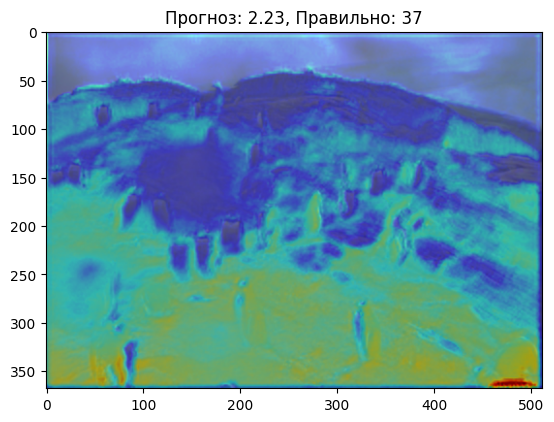

Зберігаю файл за шляхом: tests/plots/200samples_withcrop_080920251954_bl3.png


In [117]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget # Може знадобитись

# ======================================================================
# ДОДАЙТЕ ЦЕЙ КЛАС ДО ВАШОГО КОДУ
# Він каже бібліотеці, що ціллю є сам вихід моделі
class RegressionOutputTarget:
    def __call__(self, model_output):
        return model_output
# ======================================================================

# 1. Беремо модель і зображення
# Припустимо, ми взяли зображення з найбільшою помилкою
worst_sample = worst_predictions[0]
img_tensor = worst_sample['image'].unsqueeze(0).to(DEVICE) # Додаємо батч-вимір і відправляємо на GPU

# 2. Визначаємо цільовий шар (або шари)
# Це залежить від архітектури вашої моделі.
# Виведіть print(model), щоб побачити її структуру.
# Для ResNet-подібних моделей це часто останній блок.
target_layers = [best_model.res_block3] # ЗАМІНІТЬ НА ВАШ ШАР! (Тепер це список)

# 3. Створюємо об'єкт GradCAM
cam = GradCAM(model=best_model, target_layers=target_layers)

# Для регресії, де немає класів, ми не вказуємо ціль (targets=None)
# Бібліотека автоматично використає вихідне значення для обчислення градієнтів.
targets = [RegressionOutputTarget()]

# 4. Генеруємо карту активації
grayscale_cam = cam(input_tensor=img_tensor, targets=targets)
grayscale_cam = grayscale_cam[0, :] # Забираємо вимір батча

# 5. Накладаємо карту на оригінальне зображення
# Нормалізуємо зображення для коректного відображення
img_for_viz = np.transpose(worst_sample['image'].numpy(), (1, 2, 0))
img_for_viz = (img_for_viz - img_for_viz.min()) / (img_for_viz.max() - img_for_viz.min())

visualization = show_cam_on_image(img_for_viz, grayscale_cam, use_rgb=True)

# 6. Показуємо результат
plt.imshow(visualization)
pred = worst_sample['prediction']
label = worst_sample['label']
plt.title(f"Прогноз: {pred:.2f}, Правильно: {label:.0f}")
plt.show()

#####################################
from pathlib import Path
import datetime

# Створюємо об'єкт шляху з вашої кореневої директорії
root_path = Path(ROOT_DIR)
filename = f"200samples_withcrop_{datetime.datetime.now().strftime('%d%m%Y%H%M')}_bl3.png"

# Створюємо шлях до директорії, де буде збережено графік
plots_dir = Path("tests") / "plots"

# Цей рядок гарантує, що директорія існує. Якщо ні — він її створить!
# Це найкращий захист від FileNotFoundError.
plots_dir.mkdir(parents=True, exist_ok=True)

# Об'єднуємо шлях до директорії та ім'я файлу
full_path = plots_dir / filename

print(f"Зберігаю файл за шляхом: {full_path}")
plt.imsave(full_path, visualization)

#### All Grad CAMs

Знайдено 4 цільових шарів: ['res_block1', 'res_block2', 'res_block3', 'res_block4']
Зберігаю результати в директорію: tests/plots/grad_cam_08092025_210241
  -> Генерую карту для шару: res_block1...
  -> Генерую карту для шару: res_block2...
  -> Генерую карту для шару: res_block3...
  -> Генерую карту для шару: res_block4...
Усі карти згенеровано та збережено.


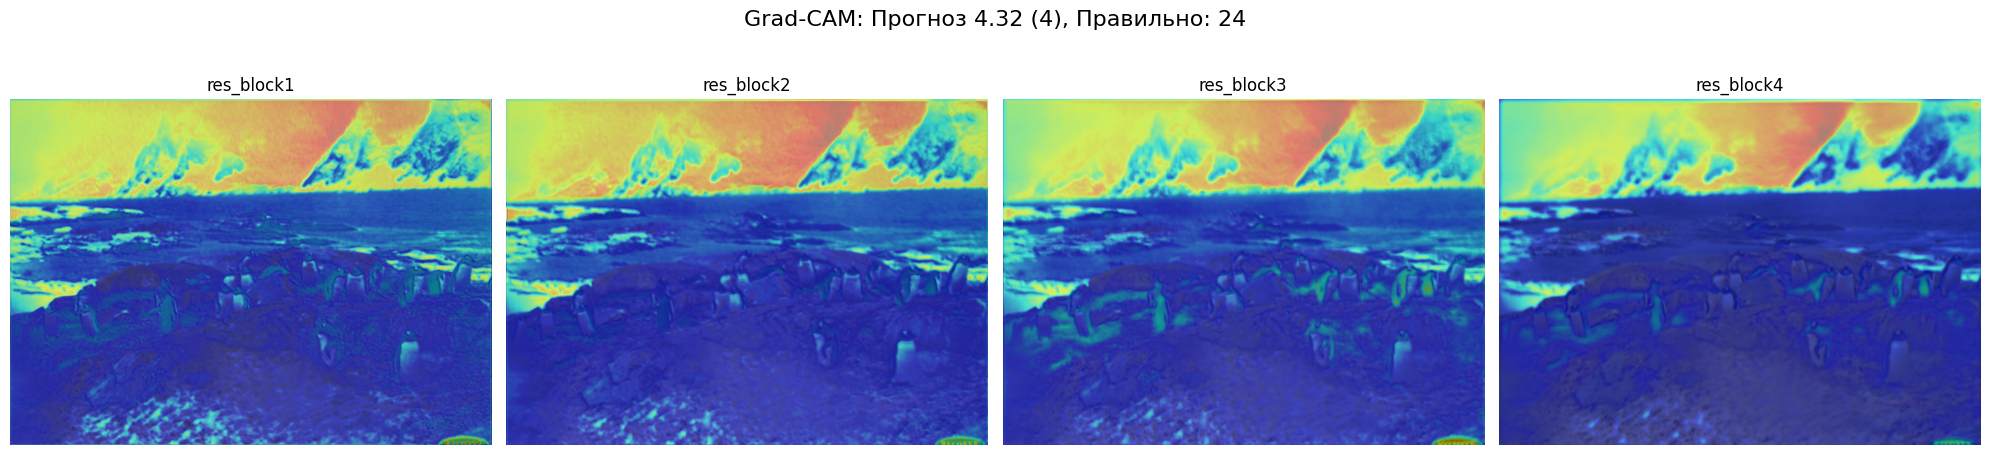

In [172]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import datetime
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# ======================================================================
# Клас-хелпер для регресії, залишається без змін
class RegressionOutputTarget:
    def __call__(self, model_output):
        return model_output
# ======================================================================

# 1. Беремо модель і зображення (з вашого коду)
# Припустимо, worst_predictions та DEVICE вже визначені
worst_sample = worst_predictions[0]
img_tensor = worst_sample['image'].unsqueeze(0).to(DEVICE)

# Готуємо зображення для візуалізації один раз
img_for_viz = np.transpose(worst_sample['image'].numpy(), (1, 2, 0))
# Нормалізуємо, щоб кольори були правильними (0-1 діапазон)
img_for_viz = (img_for_viz - img_for_viz.min()) / (img_for_viz.max() - img_for_viz.min())


# 2. АВТОМАТИЧНО знаходимо всі res_block шари в моделі
target_layers = []
target_layer_names = []
# named_children() ітерує по шарах, визначених напряму в __init__
for name, layer in best_model.named_children():
    if name.startswith("res_block"):
        target_layers.append(layer)
        target_layer_names.append(name)

print(f"Знайдено {len(target_layers)} цільових шарів: {target_layer_names}")


# 3. Створюємо унікальну директорію для збереження результатів
timestamp = datetime.datetime.now().strftime('%d%m%Y_%H%M%S')
# Припускаємо, що ROOT_DIR визначено, якщо ні, замініть на "."
try:
    root_path = Path(ROOT_DIR)
except NameError:
    root_path = Path(".") # Поточна директорія як запасний варіант

output_dir = Path("tests") / "plots" / f"grad_cam_{timestamp}"
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Зберігаю результати в директорію: {output_dir}")


# 4. Генеруємо карти активації для кожного шару і зберігаємо їх
visualizations = []
targets = [RegressionOutputTarget()]

for layer, name in zip(target_layers, target_layer_names):
    print(f"  -> Генерую карту для шару: {name}...")
    # Створюємо об'єкт GradCAM для КОЖНОГО шару
    # `target_layers` має бути списком
    cam = GradCAM(model=best_model, target_layers=[layer])

    # Генеруємо карту
    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]

    # Накладаємо карту на зображення
    visualization = show_cam_on_image(img_for_viz, grayscale_cam, use_rgb=True)
    visualizations.append(visualization)

    # Зберігаємо результат в унікальний файл
    save_path = output_dir / f"{name}.png"
    plt.imsave(save_path, visualization)

print("Усі карти згенеровано та збережено.")


# 5. Виводимо всі візуалізації на одному графіку
num_layers = len(visualizations)
# Створюємо сітку графіків: 1 рядок, num_layers колонок
fig, axes = plt.subplots(1, num_layers, figsize=(5 * num_layers, 5))

# Обробляємо випадок, коли є лише один шар (matplotlib повертає не список, а один об'єкт)
if num_layers == 1:
    axes = [axes]

# Заголовок для всього вікна з графіками
pred = worst_sample['prediction']
label = worst_sample['label']
fig.suptitle(f"Grad-CAM: Прогноз {pred:.2f} ({round(pred)}), Правильно: {label:.0f}", fontsize=16)

# Заповнюємо кожен під-графік
for ax, viz, name in zip(axes, visualizations, target_layer_names):
    ax.imshow(viz)
    ax.set_title(name)
    ax.axis('off') # Вимикаємо осі для краси

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Коригуємо розміщення, щоб вмістився suptitle
plt.show()

# LearningRate Range Test

In [ ]:
# Code in English
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np
import math

def lr_range_test(model: nn.Module,
                  train_loader: DataLoader,
                  criterion: nn.Module,
                  optimizer_class,
                  min_lr: float = 1e-7,
                  max_lr: float = 1.0,
                  device: str = 'cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Performs a learning rate range test.

    Args:
        model: The neural network model.
        train_loader: The training data loader.
        criterion: The loss function.
        optimizer_class: The class of the optimizer (e.g., optim.AdamW).
        min_lr: The starting (minimum) learning rate.
        max_lr: The ending (maximum) learning rate.
        device: The device to run the test on ('cuda' or 'cpu').
    """
    # --- 1. Initialization ---
    model.to(device)
    # Create a temporary optimizer with the minimum learning rate
    optimizer = optimizer_class(model.parameters(), lr=min_lr)

    # Save the initial state of the model to restore it later
    initial_state = model.state_dict()

    num_steps = len(train_loader)
    # Calculate the multiplicative factor for the learning rate
    lr_factor = (max_lr / min_lr) ** (1 / (num_steps - 1))

    current_lr = min_lr
    avg_loss = 0.0
    best_loss = float('inf')
    beta = 0.98  # Smoothing factor for the loss

    lrs = []
    losses = []

    # --- 2. The Loop ---
    model.train()
    pbar = tqdm(enumerate(train_loader), total=num_steps, desc="LR Range Test")

    for i, (inputs, labels) in pbar:
        inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)

        # Update learning rate for this step
        for param_group in optimizer.param_groups:
            param_group['lr'] = current_lr

        # Standard training step
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # --- 3. Record and Smooth the Loss ---
        # Use exponential moving average for a smoother plot
        current_loss = loss.item()
        avg_loss = beta * avg_loss + (1 - beta) * current_loss
        smoothed_loss = avg_loss / (1 - beta**(i + 1))

        # # Stop if the loss explodes
        # if i > 0 and smoothed_loss > 4 * best_loss:
        #     print("Loss exploded. Stopping the test.")
        #     break

        if smoothed_loss < best_loss:
            best_loss = smoothed_loss

        lrs.append(current_lr)
        losses.append(smoothed_loss)

        pbar.set_postfix(loss=f'{smoothed_loss:.4f}', lr=f'{current_lr:.2e}')

        # Update LR for the next step
        current_lr *= lr_factor

    # --- 4. Plotting ---
    plt.figure(figsize=(10, 6))
    plt.plot(lrs, losses)
    plt.xscale('log')  # Use a logarithmic scale for the x-axis
    plt.xlabel('Learning Rate')
    plt.ylabel('Loss')
    plt.title('Learning Rate Range Test')
    plt.grid(True, which="both", ls="--")
    plt.show()

    # Restore the model to its initial state
    model.load_state_dict(initial_state)
    print("Model state has been restored.")

    return lrs, losses

lrs_history, losses_history = lr_range_test(
    model=model,
    train_loader=train_dataloader,
    criterion=criterion,
    optimizer_class=optim.Adam,
    min_lr=1e-7,
    max_lr=2e-2,
    device=DEVICE
)